In [1]:
%pip install numpy matplotlib ipython ipykernel scipy numba

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
from numba import njit

import time


# Завдання 1

## Опис

Нехай $ \omega_1 $ та $ \omega_2 $ - це незалежні рівномірно розподілені на $ [0, 1] $ випадкові величини (в.в.), які отримаємо вбудованим генератором випадкових величин.
Пара незалежних в.в. $ ( \xi_1, \xi_2 ) $, які мають стандартний нормальний розподіл (тобто $ N(0, 1) $), генерується за допомогою перетворення:
$$ \xi_1 = \sqrt{-2 \ln{\omega_1}} \sin{(2 \pi \omega_2)}, \xi_2 = \sqrt{-2 \ln{\omega_1}} \cos{(2 \pi \omega_2)} $$
(в.в. $ N(0, 1) $  можна генерувати і за допомогою вбудованого генератора). Позначимо $ a = M(\xi_i) = 0, \sigma^2 = D(\xi_i) = 1 $.

Нехай спостерігається вибірка $ \bar{X} = \left( X_1, \dots, X_n \right)$, де $ X_i: N(0, 1) $.

Побудувати довірчий інтервал для:
- математичного сподівання $ a $  у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл, але дисперсія $ \sigma^2 $ невідома;
- математичного сподівання $ a $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, розподіл яких невідомий.
- дисперсії $ \sigma^2 $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл.

Всі довірчі інтервали будуються із достовірністю $ 1 - \gamma = 0.99 $ для $ n = 10^2 $, $ n = 10^4 $ та $ n = 10^6 $.
В усіх цих випадках дослідити, чи потрапляють математичне сподівання та дисперсія у побудовані довірчі інтервали, а також оцінити, як змінюється довжина довірчого інтервалу при збільшенні $ n $.
Інакше кажучи, виводити на друк:
- кількість виконаних реалізацій;
- отриману оцінку;
- побудований довірчий інтервал;
- ширину довірчого інтервалу.

**Зауваження**. Формули для побудови оцінок та довірчих інтервалів див. лекції 3 та 4.
Для випадку b) краще використовувати незміщену оцінку дисперсії.

## Вимоги

$ 1 - \gamma = 0.99 $  
$ n = 10^2, n = 10^4, n = 10^6 $

Для кожного $ n $ виводити на друк:
- кількість виконаних реалізацій;
- отриману оцінку;
- побудований довірчий інтервал;
- ширину довірчого інтервалу.

## Реалізація

Незміщена оцінка дисперсії: 
$$ \hat{\sigma}_n^2 = \frac{1}{n-1} \sum_{k=1}^{n}{\left(X_k - \left(\frac{1}{n}\sum_{k=1}^{n}{X_k}\right)\right)^2} \xrightarrow[n \to \infty]{} \sigma^2 $$


$\textbf{Довірчий інтервал для м.с. }$ $\mathbf{a}$ $\textbf{ при невідомій дисперсії }$ $\mathbf{\sigma^2}$ $\textbf{.}$ Для побудови довірчого інтервалу скористаємось твердженням леми 2, згідно якого $ \hat{\gamma}_n = \sqrt{n-1}\frac{\hat{a}_n - a}{\hat{\sigma}_n} $ має розподіл Стьюдента з $ n - 1 $ ступенем свободи. Тобто

$$ \textbf{P}\left\{\frac{\sqrt{n-1}}{\hat{\sigma}_n} \left\lvert \hat{a}_n - a \right\rvert < z\right\} = \int\limits_{-z}^{z}{s_{n-1}(u) du} = 2\int\limits_{0}^{z}{s_{n-1}(u) du} = 2 S_{n-1}(u) = 1 - \gamma $$

З останнього рівняння за таблицями для розподілу Стьюдента знаходимо $ z_{\gamma} $.

Маємо

$$ \textbf{P}\left\{\hat{a}_n - \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n < a < \hat{a}_n + \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n \right\} = 1 - \gamma $$

Звідси випливає, що

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n, \hat{a}_n + \frac{z_{\gamma}}{\sqrt{n-1}}\hat{\sigma}_n \right) \text{ з імовірністю } 1 - \gamma $$

Три відмінності від попереднього випадку: а) замість нормального розподілу використовується розподіл Стьюдента; b) $ \sigma $ замінюється на $ \hat{\sigma}_n $; 
c) $ n $ замінюється на $ n - 1 $.

$\textbf{Асимптотичний довірчий інтервал для математичного сподівання в.в., коли її розподіл невідомий.}$ В основі методу побудови асимптотичних довірчих інтервалів для параметрів, які не можна оцінити середнім арифметичним від нормально розподілених в.в., лежить центральна гранична теорема для незалежних однаково розподілених в.в.: якщо $ X_1, X_2, ... $ - послідовність незалежних однаково розподілених в.в. $ a = \textbf{M} X_i $, $ \sigma^2 = \textbf{D} X_i < \infty $, то

$$ \textbf{P}\left\{\left\lvert \frac{\sum_{i=1}^{n}{X_i} - n a}{\sigma \sqrt{n}} \right\rvert < z\right\} = 2 \Phi(z) $$

де $ \Phi(z) = \frac{1}{\sqrt{2\pi}}\int\limits_{0}^{z}{e^{-\frac{u^2}{2}} du} $ – функція Лапласа. Позначимо $ \hat{a}_n = \frac{1}{n}\sum_{k=1}^{n}{X_k} $. Якщо $ z_{\gamma} $ - розв'язок рівняння $ 2 \Phi(z) = 1 - \gamma $, то маємо довірчий інтервал:

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma} \sigma}{\sqrt{n}}, \hat{a}_n + \frac{z_{\gamma} \sigma}{\sqrt{n}} \right) \text{ з ймовірністю } 1 - \gamma $$

Оскільки, як правило, знайти точне значення дисперсії $ \sigma^2 $ немає жодної можливості, то на практиці у наведеній вище формулі використовують незміщену оцінку дисперсії: $ \hat{\sigma}_n^2 = \frac{1}{n-1} \sum_{k=1}^{n}{\left(X_k - \left(\frac{1}{n}\sum_{k=1}^{n}{X_k}\right)\right)^2} \xrightarrow[n \to \infty]{} \sigma^2 $. Тоді асимптотичний довірчий інтервал приймає вигляд:

$$ a \in \left(\hat{a}_n - \frac{z_{\gamma} \hat{\sigma}_n}{\sqrt{n}}, \hat{a}_n + \frac{z_{\gamma} \hat{\sigma}_n}{\sqrt{n}} \right) \text{ з ймовірністю } 1 - \gamma $$

$ \textbf{Довірчий інтервал для дисперсії}$ $\mathbf{\sigma^2}$ $ \textbf{.} $ Згідно з другою частиною леми 1 $ \hat{V}_n = \frac{n\hat{\sigma}_n^2}{\sigma^2} = \chi_{n-1}^{2} $, тобто має розподіл $ \chi^{2} $  з $ n-1 $ ступенем свободи. Нехай $ 1 - \gamma $ - це коефіцієнт довіри. Визначимо значення $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ з рівняння

$$ \int\limits_{z_{\gamma n}^{(1)}}^{z_{\gamma n}^{(2)}}{t_{n-1}(u) du} = 1 - \gamma $$

Очевидно, що числа $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ визначаються неоднозначно. Тому додатково вимагаємо:

$$ \int\limits_{0}^{z_{\gamma n}^{(1)}}{t_{n-1}(u) du} = \frac{\gamma}{2}, \qquad \int\limits_{z_{\gamma n}^{(2)}}^{\infty}{t_{n-1}(u) du} = \frac{\gamma}{2} $$

У цьому випадку числа $ z_{\gamma n}^{(1)} $ та $ z_{\gamma n}^{(2)} $ визначаються однозначно. Їхні значення знаходять з таблиць $ \chi^{2} $ розподілу з $ n-1 $ ступенем свободи. Таким чином, маємо:

$$ \textbf{P}\left\{ z_{\gamma n}^{(1)} < \frac{n \hat{\sigma}_n^2}{\sigma^2} < z_{\gamma n}^{(2)} \right\} = \int\limits_{z_{\gamma n}^{(1)}}^{z_{\gamma n}^{(2)}}{t_{n-1}(u) du} = 1 - \gamma $$

Звідси маємо: $ \frac{n \hat{\sigma}_n^2}{z_{\gamma n}^{(2)}} < \sigma^2 < \frac{n \hat{\sigma}_n^2}{z_{\gamma n}^{(1)}} $ з ймовірністю $ 1 - \gamma $.

In [3]:

class InfoTask1:
    def __init__(self, title: str = None, n: int = None, estimation: float = None, interval: list[float] = None):
        self.title = title
        self.n = n
        self.estimation  = estimation
        self.interval = interval

    @property
    def width(self):
        return None if self.interval is None else self.interval[1] - self.interval[0]
    
    def print_info(self):
        width_separate = 100
        print(self.title)
        print("_"*width_separate)
        print(f"[Кількість виконаних реалізацій] n = {self.n}")
        print("_"*width_separate)
        print(f"[Отримана оцінка] {self.estimation}")
        print(f"[Довірчий інтервал] {self.interval}")
        print(f"[Ширина довірчого інтервалу] {self.width}")
        print("_"*width_separate)
        print("\n")

class PlotTask1:
    @staticmethod
    def plot(suptitle: str = None, title: str = None, ns: list[int] = None, intervals: list[list[float]] = None, estimations: list[float] = None):
        plt.suptitle(f"{suptitle}")
        plt.title(f"{title}")
        plt.xlabel('Значення')
        plt.ylabel('Розмір')
        plt.yticks(list(range(len(ns))), ns, fontsize=12)

        for y, (n, interval, estimation) in enumerate(zip(ns, intervals, estimations)):
            plt.plot(interval, [y, y], zorder=1, marker='|', markersize=16)
            plt.scatter(estimation, y, zorder=2, label=f"Отримана оцінка {estimation:.4f} для n = 10^{len(str(n))-1}")
            y_offset = 0.1
            plt.text(interval[0], y + 2*y_offset, f"{interval[0]:.4f}", ha='center', va='bottom', color='blue')
            plt.text(interval[1], y - 2*y_offset, f"{interval[1]:.4f}", ha='center', va='top', color='blue')
            plt.text(estimation, y - 0.5*y_offset, f"{estimation:.4f}", ha='center', va='top', color='red')

        x_range = intervals[0][1] - intervals[0][0]
        plt.xlim(intervals[0][0] - 0.2*x_range, intervals[0][1] + 0.2*x_range)
        y_range = len(ns) - 1
        plt.ylim(-0.2*y_range, y_range + 0.6*y_range)

        plt.legend(loc="upper center")
        plt.show()

def generate_data(n):
    amount = n // 2
    w1 = np.random.uniform(0, 1, amount)
    w2 = np.random.uniform(0, 1, amount)
    
    xi_1 = np.sqrt(-2 * np.log(w1)) * np.sin(2 * np.pi * w2)
    xi_2 = np.sqrt(-2 * np.log(w1)) * np.cos(2 * np.pi * w2)
    return np.concatenate((xi_1, xi_2))

def _interval(interval, info):
    if info is not None:
        info.interval = interval
    return interval


# довірчий інтервал для математичного сподівання $ a $  у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл, але дисперсія $ \sigma^2 $ невідома;
def normal_distribution_mean_estimation_without_known_variance(n: float, gamma: float, X_mean: float, sigma: float, info: InfoTask1 = None) -> list[float]:
    """
    a) Довірчий інтервал для математичного сподівання при невідомій дисперсії (Через розподіл Стьюдента)
    """
    z_value = stats.t.ppf(1 - gamma / 2, n - 1)
    a = z_value * sigma / np.sqrt(n - 1)
    interval = [X_mean - a, X_mean + a]
    return _interval(interval, info)

# довірчий інтервал для математичного сподівання $ a $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, розподіл яких невідомий.
def unknown_distribution_mean_estimation(n: float, gamma: float, X_mean: float, sigma: float, info: InfoTask1 = None) -> list[float]:
    """
    b) Довірчий інтервал для математичного сподівання при невідомому розподілі (Через асимптотичний довірчий інтервал для математичного сподівання в.в., коли її розподіл невідомий)
    """
    z_value = stats.norm.ppf(1 - gamma / 2)
    a = z_value * sigma / np.sqrt(n)
    interval = [X_mean - a, X_mean + a]
    return _interval(interval, info)

# довірчий інтервал для дисперсії $ \sigma^2 $ у припущенні, що спостерігаються в.в. $ \{ X_i \} $, які мають нормальний розподіл.
def normal_distribution_var_estimation(n: float, gamma: float, X_var: float, info: InfoTask1 = None) -> list[float]:
    """
    c) Довірчий інтервал для дисперсії при нормальному розподілі
    """
    upper = stats.chi2.ppf(1 - gamma / 2, n - 1)
    lower = stats.chi2.ppf(gamma / 2, n - 1)
    interval = [n * X_var / upper, n  * X_var / lower]
    return _interval(interval, info)
    

In [4]:
confidence_level = 0.99
gamma = 1 - confidence_level

numbers = [10**2, 10**4, 10**6]
infos = [
    "[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2",
    "[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X",
    "[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X"
]

[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.055073709679697005
[Довірчий інтервал] [np.float64(-0.219974821657631), np.float64(0.330122241017025)]
[Ширина довірчого інтервалу] 0.550097062674656
____________________________________________________________________________________________________


[Необхідно] Довірчий інтервал для математичного сподівання a при нормальному розподілі X але невідомій дисперсії sigma^2
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
__________________________________________________________________________________________________

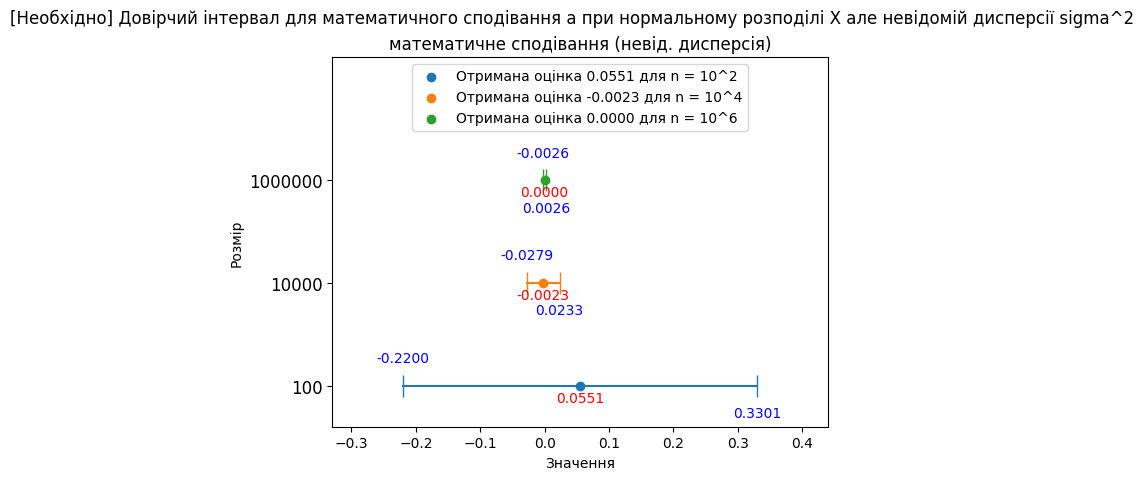

[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.014336702977333714
[Довірчий інтервал] [np.float64(-0.22458646830575643), np.float64(0.25325987426042385)]
[Ширина довірчого інтервалу] 0.4778463425661803
____________________________________________________________________________________________________


[Необхідно] Довірчий інтервал для математичного сподівання a при невідомому розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
____________________________________________________________________________________________________
[Отримана оцінка] -0.0024949424282247564
[Довірчий інтерва

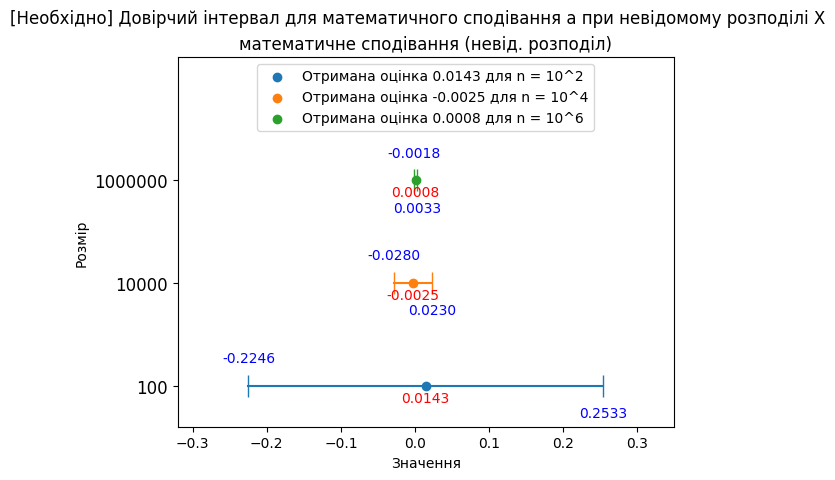

[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 100
____________________________________________________________________________________________________
[Отримана оцінка] 0.9001496778140071
[Довірчий інтервал] [np.float64(0.6476512769516304), np.float64(1.3534028757438958)]
[Ширина довірчого інтервалу] 0.7057515987922655
____________________________________________________________________________________________________


[Необхідно] Довірчий інтервал для дисперсії sigma^2 при нормальному розподілі X
____________________________________________________________________________________________________
[Кількість виконаних реалізацій] n = 10000
____________________________________________________________________________________________________
[Отримана оцінка] 1.0061030207031372
[Довірчий інтервал] [np.float64(0.97048478

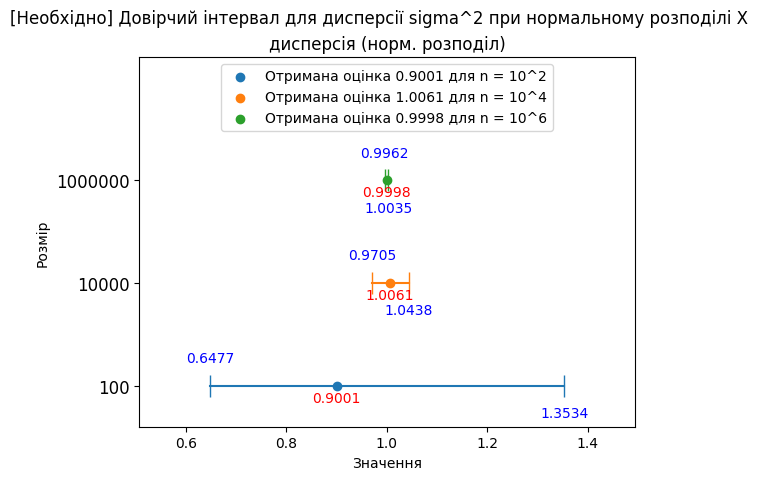

In [5]:
info = InfoTask1()

for info_index in range(len(infos)):
    ns = []
    intervals = []
    estimations = []
    info.title = infos[info_index]
    for n in numbers:
        info.n = n
        X = generate_data(n)
        
        X_mean = np.mean(X)
        X_var = np.var(X)
        X_var_d = np.var(X, ddof=1)
        if info_index != 2:
            info.estimation = X_mean
        else:
            info.estimation = X_var
        
        match info_index:
            case 0:
                normal_distribution_mean_estimation_without_known_variance(n, gamma, X_mean, np.sqrt(X_var), info)
                subtitle = "математичне сподівання (невід. дисперсія)"
            case 1:
                unknown_distribution_mean_estimation(n, gamma, X_mean, np.sqrt(X_var_d), info)
                subtitle = "математичне сподівання (невід. розподіл)"
            case 2:
                normal_distribution_var_estimation(n, gamma, X_var, info)
                subtitle = "дисперсія (норм. розподіл)"

        info.print_info()
        ns.append(info.n)
        intervals.append(info.interval)
        estimations.append(info.estimation)
    PlotTask1.plot(info.title, subtitle, ns, intervals, estimations)
    # print("="*100)
    # print("\n")


# Завдання 2

## Опис

Обчислення ймовірності $Q_n = P\{ \xi_1 + \dots + \xi_2 \}$  трьома способами із дослідженням швидкості збіжності, тобто кількості реалізацій, витрачених різними алгоритмами на побудову оцінки із заданими достовірністю та відносною похибкою (інакше кажучи, виявлення найкращого методу для тих чи інших варіантів задачі).

Випадкові величини $\{ \xi_i \}$ є незалежними та однаково розподіленими (розподіл Вейбулла):
$$ F(u) = P\{ \xi_i < u \} = 1 - e^{-u^2}, u >= 0 $$

В.в. $ \eta $  може мати один з двох розподілів:
$$ \text{A. } G(u) = P\{ \eta < u \} = 1 - \frac{1}{(1 + u)^2}, u >= 0, M \eta = \int\limits_0^{\infty}{[1 - G(u)]du} = \int\limits_0^{\infty}{\frac{1}{(1 + u)^2} du} = 1 $$
$$ \text{B. } G(u) = P\{ \eta < u \} = 1 - e^{-u}, u >= 0, M \eta = \int\limits_0^{\infty}{[1 - G(u)]du} = \int\limits_0^{\infty}{e^{-u} du} = 1 $$

Зауваження 1. Нехай $ \omega, \omega_1, \omega_2, \dots $ - послідовність незалежних рівномірно розподілених на відрізку $ [0, 1] $ в.в. (послідовність псевдовипадкових чисел). Тоді моделювання в.в. $ \{ \xi_i \} $ та $ \eta $ відбувається за формулами:

$ \xi_i = F^{-1}(\omega_i), \text{ тобто } 1 - e^{-\xi_i^2} = 1 - \omega_i (\omega_i \text{ та } 1 - \omega_i \text{ мають один і той же рівномірний розподіл }) \Rightarrow \xi_i = (- \ln{\omega_i})^{1/2}; $

Випадок А:
$ \eta = G^{-1}(\omega) $, тобто $ 1 - \frac{1}{(1 + \eta)^2} = 1 - \omega \Rightarrow \eta = \frac{1}{\omega^{1/2}} - 1 $;

Випадок В:
$ \eta = G^{-1}(\omega) $, тобто $ 1 - e^{-\eta} = 1 - \omega \Rightarrow \eta = -\ln{\omega} $.

Зауваження 2. Загальна схема обчислення ймовірності $ Q_n $ виглядає наступним чином. Нехай $ \hat{q}_1, \hat{q}_2, \dots $ - незміщені оцінки ймовірності $ Q_n $.
Позначимо
$$ \hat{Q}_n(N) = \frac{1}{N} \sum\limits_{i=1}^{n}{\hat{q}_i}, \qquad \hat{\sigma}_n^2(N) = \frac{1}{N-1} \left( \sum\limits_{i=1}^{n}{\hat{q}_i^2} - N \hat{Q}_n^2(N) \right) = \frac{1}{N-1} \left( \sum\limits_{i=1}^{n}{(\hat{q}_i - \hat{Q}_n(N))^2} \right)$$
- незміщена оцінка для $ Q_n $ та вибіркова дисперсія, побудовані за $ N $ реалізацій того чи іншого алгоритму.

Кількість реалізацій $ N^* $, які потрібно здійснити для обчислення ймовірності $ Q_n $ із заданими достовірністю $ 1 - \gamma $ та відносною похибкою $ \epsilon $ обчислюється за формулою:
$$ N^* = \min\{ N > N_0: N >= \frac{z_{\gamma}^2 \hat{\sigma}_n^2(N)}{\epsilon^2 \hat{Q}_n^2(N)} \}, $$
де $ N_0 $ - початкова кількість реалізацій, яка потрібна для “стабілізації” вибіркової дисперсії, а $ z_{\gamma} $ - це коефіцієнт, який знаходиться з рівняння $ 2 \Phi(z) = 1 - \gamma $ ($ \Phi(z) $ - це функція Лапласа).

В усіх наведених вище випадках обчислення вести із достовірністю 0.99 та відносною похибкою 1%, тобто $ z_{\gamma} = 2.575 $ і $ \epsilon = 0.01 $. Параметр $ n $ приймає наступні значення: 1, 10, 100, 200. В.в. $ \eta $ має один з двох розподілів (випадки А та В). Для обчислення $ Q_n $ використовуємо один з трьох методів статистичного моделювання та з’ясовуємо, який з них більш доцільно використовувати.

## Методи

**Метод 1.** Стандартний метод Монте-Карло:
$ Q_n = M I(\xi_1 + \dots + \xi_n < \eta) $, тобто $ \hat{q}_i = I(\xi_1^{(i)} + \dots + \xi_n^{(i)} < \eta_i) $,
де $ I(\dot) $ - індикаторна функція (індекс $ "i" $ відноситься до $ i $-ї реалізації алгоритму).

**Метод 2.** Використовуємо співвідношення:
$$ Q_n = \int\limits_{0}^{\infty}{[1 - G(u)] dP\{ \xi_1 + \dots + \xi_n < u \}} = M[1 - G(\xi_1 + \dots + \xi_n)], $$
тобто
   $$ \hat{q}_i = \frac{1}{\left( 1 + \xi_1^{(i)} + \dots + \xi_n^{(i)} \right)^2} \text{ (випадок А);}$$
   $$ \hat{q}_i = e^{- \left( \xi_1^{(i)} + \dots + \xi_n^{(i)} \right)} \text{ (випадок В).}$$

**Метод 3.** Цей метод ґрунтується на формулі:
$$ Q_n = \int\limits_{0}^{\infty}{P\{ \xi_1 + \dots + \xi_n < u \} dG(u)} = M_{\eta} P\{ \xi_1 + \dots + \xi_n < \eta \}. $$
Оскільки ймовірність $ P\{ \xi_1 + \dots + \xi_n < u \} $ не може бути обчисленою за явною аналітичною формулою (як у попередньому випадку), то для обчислення ймовірності $ P\{ \xi_1 + \dots + \xi_n < u \} $ (згортка) використовуємо наступний простий алгоритм побудови оцінки в одній реалізації.
1. Моделюємо значення в.в. $ \eta $. Нехай $ \eta = u $.
2. Як початкові значення виберемо: $ T = u, \hat{q} = 1 $ (початкова оцінка ймовірності $ P\{ \xi_1 + \dots + \xi_n < u \} $). 
3. У циклі $ n $ разів повторюємо наступні кроки алгоритму:
   - обчислюємо $ \gamma = P\{ \xi < T \} = 1 - e^{-T^2} $;
   - як нове значення для $ \hat{q} $ обираємо $ \hat{q} \cdot \gamma $;
   - моделюємо в.в. $ \xi^* $ з розподілом
   $$ P\{ \xi^* < \nu \} = P\{ \xi < \nu \vert \xi < T \} = \frac{1 - e^{-\nu^2}}{1 - e^{-T^2}}, \nu \in [0, T], $$
   а саме $ \xi^* = \left( -\ln \left( 1 - \omega \cdot \left( 1 - e^{-T^2} \right) \right) \right)^{1/2} $, де $ \omega $ має рівномірний розподіл на $ [0, 1] $;
   - замість $ T $ обираємо $ T - \xi^* $.
4. Коли цикл завершено, як оцінку для $ Q_n $ обираємо отримане значення $ \hat{q} $.

## Вимоги

$ z_{\gamma} = 2.575 $

$ 1 - \gamma = 0.99 $

Для кожного значення параметра $ n $ (1, 10, 100, 200), для випадків А та В для кожного з трьох методів виводити на друк:
- оцінку $ \hat{Q}_n(N^*) $;
- вибіркову дисперсію $ \hat{\sigma}_n^2(N^*)$;
- відповідний довірчий інтервал;
- кількість виконаних реалізацій $ N^* $, які знадобились для побудови оцінки із достовірністю 0.99 та відносною похибкою 1%

## Реалізація

In [6]:

def sci(x):
    if x is None or x is np.nan:
        return None, None
    try:
        exp = int(np.floor(np.log10(np.abs(x))))
        coef = x / 10**exp
        return coef if x == np.abs(x) else -coef, exp
    except Exception as e:
        # print(e)
        return x, 0

def sci_notation_latex(x):
    coef, exp = sci(x)
    return rf"${coef:.2f} \cdot 10^{{{exp}}}$"

def sci_notation(x):
    coef, exp = sci(x)
    return f"{coef:.2f} * 10^{exp}"

class InfoTask2:
    def __init__(self, method: str = None, case: str = None, n: int = None, estimation: float = None, var: float = None, interval: list[float] = None, n_used: int = None):
        self.method = method
        self.case = case
        self.n = n
        self.estimation  = estimation
        self.var  = var
        self.interval = interval
        self.n_used = n_used

    def print_info(self):
        width_separate = 100
        print(f"[Name] {self.method}")
        print("_"*width_separate)
        print(f"[Випадок] {self.case}")
        print(f"[Кількість параметру n] {sci_notation(self.n)}")
        print("_"*width_separate)
        print(f"[Отримана оцінка] {sci_notation(self.estimation)}")
        print(f"[Отримана дисперсія] {sci_notation(self.var)}")
        print(f"[Довірчий інтервал] {self.interval}")
        print(f"[Кількість виконаних реалізацій] {self.n_used}")
        print("_"*width_separate)
        print("\n")
        # if self.interval:
        #     plt.ylim(-0.5, 0.5)
        #     plt.yticks([])
        #     plt.plot(self.interval, [0, 0], color='blue', zorder=1, marker='|', markersize=16)
        #     plt.scatter(self.estimation, 0, color='red', zorder=2)
        #     y_offset = 0.05 
        #     plt.text(self.interval[0], 2*y_offset, f"{self.interval[0]:.4f}", ha='center', va='bottom', color='blue')
        #     plt.text(self.interval[1], -2*y_offset, f"{self.interval[1]:.4f}", ha='center', va='top', color='blue')
        #     plt.text(self.estimation, -0.5*y_offset, f"{self.estimation:.4f}", ha='center', va='top', color='red')
        #     plt.title(f"Довірчий інтервал для {self.method} Випадок {self.case} n = {self.n}")
        #     plt.show()

In [7]:
class PlotTask2:
    @staticmethod
    def plot(suptitle: str = None, title: str = None, ns: list[int] = None, intervals: list[list[float]] = None, estimations: list[float] = None):
        plt.suptitle(f"{suptitle}")
        plt.title(f"{title}")
        plt.xlabel('Значення')
        plt.ylabel('Розмір')
        plt.yticks(list(range(len(ns))), ns, fontsize=12)

        for y, (n, interval, estimation) in enumerate(zip(ns, intervals, estimations)):
            plt.plot(interval, [y, y], zorder=1, marker='|', markersize=16)
            plt.scatter(estimation, y, zorder=2, label=f"Отримана оцінка {sci_notation_latex(estimation)} для n = {n}")
            y_offset = 0.05
            plt.text(interval[0], y + 2*y_offset, f"{sci_notation_latex(interval[0])}", ha='center', va='bottom', color='blue')
            plt.text(interval[1], y - 3*y_offset, f"{sci_notation_latex(interval[1])}", ha='center', va='top', color='blue')
            plt.text(estimation, y + 1*y_offset, f"{sci_notation_latex(estimation)}", ha='center', va='top', color='red')

        intervals = np.array(intervals)
        interval = [np.min(intervals[:, 0]), np.max(intervals[:, 1])]
        x_range = interval[1] - interval[0]
        plt.xlim(interval[0] - 0.2*x_range, interval[1] + 0.2*x_range)
        y_range = len(ns) - 1
        plt.ylim(-0.2*y_range, y_range + 0.6*y_range)

        plt.legend(loc="upper center")
        plt.show()

In [8]:
@njit
def generate_xi(size: int):
    omega = np.random.uniform(0, 1, size)
    return np.sqrt(-np.log(omega))

@njit
def generate_eta(case: str, size: int):
    omega = np.random.uniform(0, 1, size)
    match case:
        case 'A':
            return 1 / np.sqrt(omega) - 1
        case 'B':
            return -np.log(omega)

@njit
def monte_carlo_method(n: int, case: str) -> float:
    xi_sum = sum(generate_xi(n))
    eta = generate_eta(case, 1)[0]
    # print(xi_sum , eta)
    q_i = np.float64(xi_sum < eta)
    return q_i

@njit
def method_2(n: int, case: str) -> float:
    xi_sum = sum(generate_xi(n))
    if case == 'A':
        return 1 / (1 + xi_sum)**2
    elif case == 'B':
        return np.exp(-xi_sum)

@njit
def method_3(n: int, case: str) -> float:
    eta = generate_eta(case, 1)[0]
    q_hat = 1
    T = eta
    for _ in range(n):
        gamma = 1 - np.exp(-T**2)
        q_hat *= gamma
        omega = np.random.uniform(0, 1)
        xi_star = np.sqrt(-np.log(1 - omega*gamma))
        T -= xi_star
        if T <= 0:
            q_hat = 0
            break
    return q_hat

[Current N*] 1000.0
[Formula N*] 118180.14194750297

[Current N*] 1000.0
[Formula N*] 4086064.580205328

[Current N*] 1000000.0
[Formula N*] 5950600.789582925

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Current N*] 5000.0
[Current N*] 6000.0
[Current N*] 7000.0
[Current N*] 8000.0
[Current N*] 9000.0
[Current N*] 10000.0
[Formula N*] 663128812.8812981

[Current N*] 1000000.0
[Formula N*] 483921403.94835186

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Current N*] 5000.0
[Current N*] 6000.0
[Current N*] 7000.0
[Current N*] 8000.0
[Current N*] 9000.0
[Current N*] 10000.0
[Current N*] 11000.0
[Current N*] 12000.0
[Current N*] 13000.0
[Current N*] 14000.0
[Current N*] 15000.0
[Current N*] 16000.0
[Current N*] 17000.0
[Current N*] 18000.0
[Current N*] 19000.0
[Current N*] 20000.0
[Current N*] 21000.0
[Formula N*] 1392497559.4075887

[Current N*] 1000000.0
[Formula N*] 2550176628.5156794



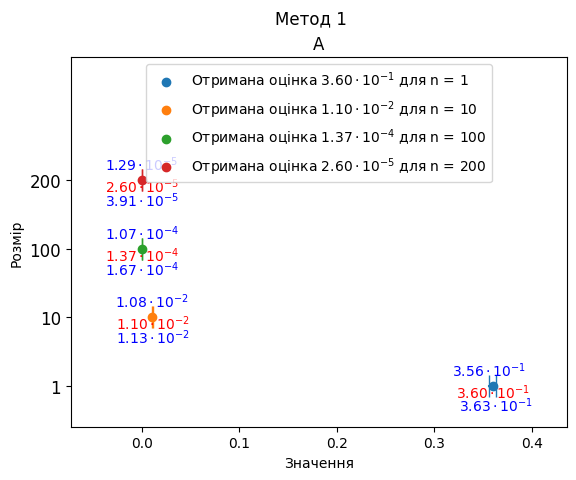

[Current N*] 1000.0
[Formula N*] 84969.05219570384

[Current N*] 1000.0
[Current N*] 2000.0
[Formula N*] 132678839.41971022

[Current N*] 1000000.0
[Formula N*] 169515065.31123057

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Current N*] 5000.0
[Current N*] 6000.0
[Current N*] 7000.0
[Current N*] 8000.0
[Current N*] 9000.0
[Current N*] 10000.0
[Current N*] 11000.0
[Current N*] 12000.0
[Current N*] 13000.0
[Current N*] 14000.0
[Current N*] 15000.0
[Current N*] 16000.0
[Current N*] 17000.0
[Current N*] 18000.0
[Current N*] 19000.0
[Current N*] 20000.0
[Current N*] 21000.0
[Current N*] 22000.0
[Current N*] 23000.0
[Current N*] 24000.0
[Current N*] 25000.0
[Current N*] 26000.0
[Current N*] 27000.0
[Current N*] 28000.0
[Current N*] 29000.0
[Current N*] 30000.0
[Current N*] 31000.0
[Current N*] 32000.0
[Current N*] 33000.0
[Current N*] 34000.0
[Current N*] 35000.0
[Current N*] 36000.0
[Current N*] 37000.0
[Current N*] 38000.0
[Current N*] 39000.0
[Current 

C:\Users\dadmo\AppData\Local\Temp\ipykernel_30340\1440304520.py:5: RuntimeWarning: divide by zero encountered in log10
  exp = int(np.floor(np.log10(np.abs(x))))


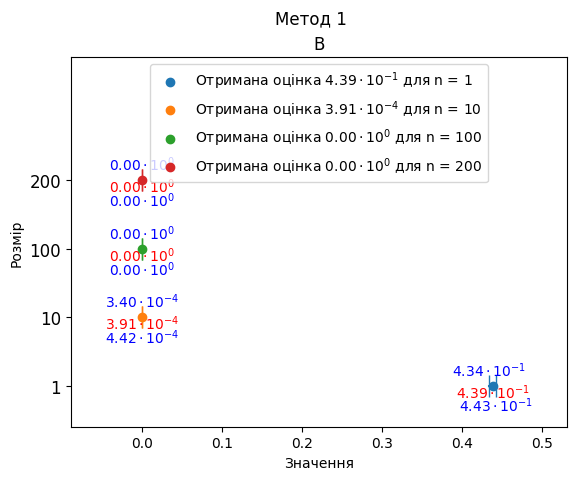

[Current N*] 1000.0
[Formula N*] 16059.234681521604

[Current N*] 1000.0
[Formula N*] 7653.8837934780295

[Current N*] 1000.0
[Formula N*] 790.1878883459947

[Current N*] 1000.0
[Formula N*] 430.17291634516823



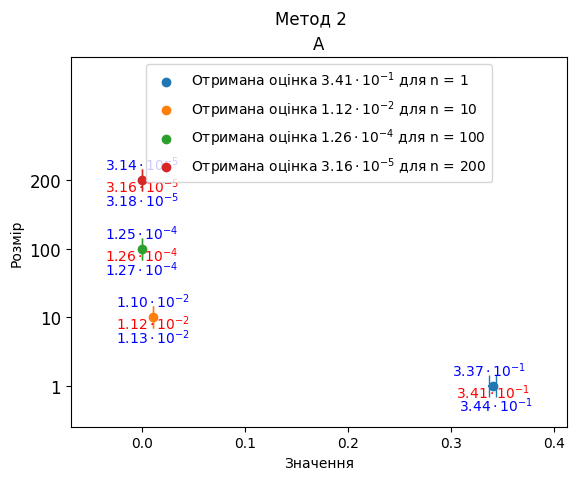

[Current N*] 1000.0
[Formula N*] 11569.096383998321

[Current N*] 1000.0
[Formula N*] 374436.7365983457

[Current N*] 1000.0
[Formula N*] 21932282.626292177

[Current N*] 1000000.0
[Formula N*] 601427542.12471

[Current N*] 1000.0
[Formula N*] 34682374.50454087

[Current N*] 1000000.0
[Formula N*] 12463428239.152672



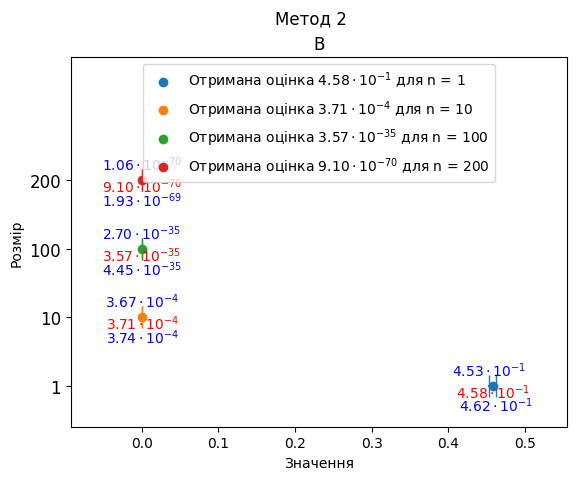

[Current N*] 1000.0
[Formula N*] 74996.9506240072

[Current N*] 1000.0
[Formula N*] 4279068.862296727

[Current N*] 1000000.0
[Formula N*] 5560604.7469280735

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Formula N*] 265291322.83070558

[Current N*] 1000000.0
[Formula N*] 482911294.0385066

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Current N*] 5000.0
[Current N*] 6000.0
[Current N*] 7000.0
[Current N*] 8000.0
[Current N*] 9000.0
[Current N*] 10000.0
[Current N*] 11000.0
[Current N*] 12000.0
[Current N*] 13000.0
[Current N*] 14000.0
[Current N*] 15000.0
[Current N*] 16000.0
[Current N*] 17000.0
[Current N*] 18000.0
[Current N*] 19000.0
[Current N*] 20000.0
[Current N*] 21000.0
[Current N*] 22000.0
[Current N*] 23000.0
[Current N*] 24000.0
[Current N*] 25000.0
[Current N*] 26000.0
[Current N*] 27000.0
[Current N*] 28000.0
[Current N*] 29000.0
[Current N*] 30000.0
[Current N*] 31000.0
[Current N*] 32000.0
[Current N

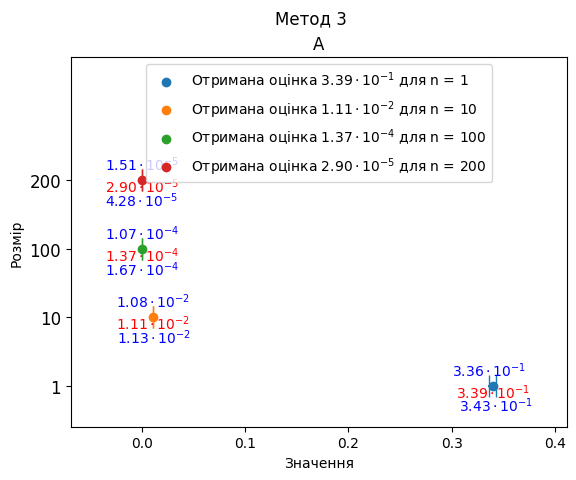

[Current N*] 1000.0
[Formula N*] 44387.09046504535

[Current N*] 1000.0
[Formula N*] 66367254.206931815

[Current N*] 1000000.0
[Formula N*] 128542897.45191842

[Current N*] 1000.0
[Current N*] 2000.0
[Current N*] 3000.0
[Current N*] 4000.0
[Current N*] 5000.0
[Current N*] 6000.0
[Current N*] 7000.0
[Current N*] 8000.0
[Current N*] 9000.0
[Current N*] 10000.0
[Current N*] 11000.0
[Current N*] 12000.0
[Current N*] 13000.0
[Current N*] 14000.0
[Current N*] 15000.0
[Current N*] 16000.0
[Current N*] 17000.0
[Current N*] 18000.0
[Current N*] 19000.0
[Current N*] 20000.0
[Current N*] 21000.0
[Current N*] 22000.0
[Current N*] 23000.0
[Current N*] 24000.0
[Current N*] 25000.0
[Current N*] 26000.0
[Current N*] 27000.0
[Current N*] 28000.0
[Current N*] 29000.0
[Current N*] 30000.0
[Current N*] 31000.0
[Current N*] 32000.0
[Current N*] 33000.0
[Current N*] 34000.0
[Current N*] 35000.0
[Current N*] 36000.0
[Current N*] 37000.0
[Current N*] 38000.0
[Current N*] 39000.0
[Current N*] 40000.0
[Current

C:\Users\dadmo\AppData\Local\Temp\ipykernel_30340\1440304520.py:5: RuntimeWarning: divide by zero encountered in log10
  exp = int(np.floor(np.log10(np.abs(x))))


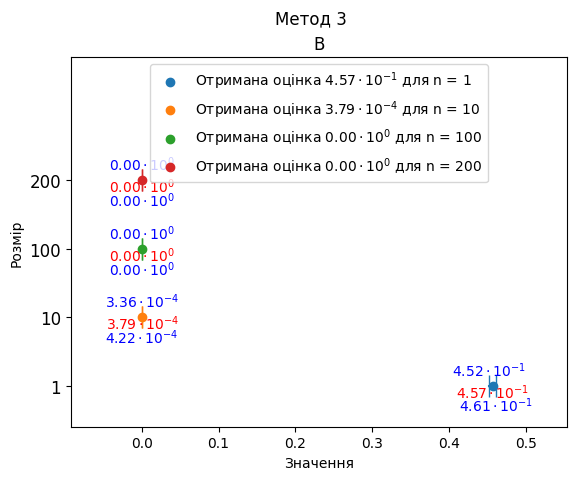

[Метод 1] Випадок A, Кількість 1  :   2.5874s
[Метод 1] Випадок A, Кількість 10 :   0.3572s
[Метод 1] Випадок A, Кількість 100:   1.5597s
[Метод 1] Випадок A, Кількість 200:   2.8971s
[Метод 1] Випадок B, Кількість 1  :   0.0239s
[Метод 1] Випадок B, Кількість 10 :   0.3730s
[Метод 1] Випадок B, Кількість 100:   2.0008s
[Метод 1] Випадок B, Кількість 200:   3.3061s
[Метод 2] Випадок A, Кількість 1  :   0.4188s
[Метод 2] Випадок A, Кількість 10 :   0.0023s
[Метод 2] Випадок A, Кількість 100:   0.0019s
[Метод 2] Випадок A, Кількість 200:   0.0032s
[Метод 2] Випадок B, Кількість 1  :   0.0023s
[Метод 2] Випадок B, Кількість 10 :   0.0931s
[Метод 2] Випадок B, Кількість 100:   1.4411s
[Метод 2] Випадок B, Кількість 200:   2.8049s
[Метод 3] Випадок A, Кількість 1  :   0.4303s
[Метод 3] Випадок A, Кількість 10 :   0.4486s
[Метод 3] Випадок A, Кількість 100:   2.1941s
[Метод 3] Випадок A, Кількість 200:   4.1175s
[Метод 3] Випадок B, Кількість 1  :   0.0095s
[Метод 3] Випадок B, Кількість 10 

In [9]:
@njit
def task_2(method: callable, case: str, n: int, z_value: float, epsilon: float, N_start: int = 1000, N_max: int = int(1e6)) -> tuple:
    N = 0
    N_needed = N_start 
    q_ = np.zeros(N_max)
    while N < N_needed:
        q_[N] = method(n, case)
        N += 1
        if N == N_needed:
            print("[Current N*]", N_needed)
            q = q_[:N+1]
            mean = np.mean(q)
            if mean == 0:
                N_needed += N_start
            else:
                Q_hat = mean
                sigma_sq_hat = np.var(q) * N / (N - 1)  #, ddof=1
                N_star = (z_value**2 * sigma_sq_hat)/(epsilon**2 * Q_hat**2)
                print("[Formula N*]", N_star)
                print()
                N_needed = min(N_max, N_star)
            N_needed = min(N_max, N_needed)
    a = z_value * np.sqrt(sigma_sq_hat) / np.sqrt(N)
    interval = [Q_hat - a, Q_hat + a]
    return Q_hat, sigma_sq_hat, interval, N


epsilon = 0.01
confidence_level = 0.99
gamma = 1 - confidence_level

z_value = 2.575
# z_value = stats.norm.ppf(1 - gamma/2)

methods = {"Метод 1": monte_carlo_method, "Метод 2": method_2, "Метод 3": method_3}
# methods = {"Метод 2": method_2, "Метод 3": method_3}
cases = ["A", "B"]
numbers = [1, 10, 100, 200]
# numbers = [1, 10]

time_spent = []
for method in methods:
    for cas in cases:
        intervals = []
        estimations = []
        for n in numbers:
            start = time.perf_counter()
            Q_hat, sigma_sq_hat, interval, N_needed = task_2(methods[method], cas, n, z_value, epsilon)
            time_spent.append([time.perf_counter() - start, method, cas, n])
            info = InfoTask2(method, cas, n, Q_hat, sigma_sq_hat, interval, N_needed)
            # info.print_info()
            intervals.append(interval)
            estimations.append(Q_hat)
        PlotTask2.plot(method, cas, numbers, intervals, estimations)
for time in time_spent:
    print(f"[{time[1]}] Випадок {time[2]}, Кількість {time[3]:<3}: {time[0]:8.4f}s")